# Stroke Predictions Analysis & Model

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from pprint import pprint
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
import functions as fn
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTENC
from eli5.sklearn import PermutationImportance
import eli5
import shap
from IPython.display import display
import scipy.stats as stats
import pickle
import requests
from dython.nominal import associations
from scipy.stats import randint, uniform


sns.set_style("darkgrid")
sns.set_context("notebook")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

### Table of Contents

1. `Introduction`

2. `EDA`

    2.1. `Regression on BMI`
    
    2.2. `Missing Data Imputation`

3. `Statistical Inference`

4. `Modelling`
    
    4.1. `Cross Validation & Tuning`

    4.2. `Permutation Importance`

    4.3. `SHAP Values`
    
5. `Model Testing`

6. `Avenues for Improvement`

Let's first take a peek at the data format. We seem to have 11 columns and 5110 values. We can already see that most of the values are categorical bar `BMI`, `age` & `avg_glucose_level`. While the columns are relatively self explanatory, I paste the explanations of each column for clarity's sake:
1) `id`: unique identifier
2) `gender`: "Male", "Female" or "Other"
3) `age`: age of the patient
4) `hypertension`: 0 if the patient doesn't have hypertension, 1 if the patient has hypertension
5) `heart_disease`: 0 if the patient doesn't have any heart diseases, 1 if the patient has a heart disease
6) `ever_married`: "No" or "Yes"
7) `work_type`: "children", "Govt_jov", "Never_worked", "Private" or "Self-employed"
8) `Residence_type`: "Rural" or "Urban"
9) `avg_glucose_level`: average glucose level in blood
10) `bmi`: body mass index
11) `smoking_status`: "formerly smoked", "never smoked", "smokes" or "Unknown"
12) `stroke`: 1 if the patient had a stroke or 0 if not
*Note: "Unknown" in smoking_status means that the information is unavailable for this patient

In [27]:
healthcare_data = pd.read_csv('healthcare-dataset-stroke-data.csv', index_col = ['id'])
pprint(f"Number of records: {healthcare_data.shape[0]}")
pprint(f"Number of columns: {healthcare_data.shape[1]}")
healthcare_data.head()

'Number of records: 5110'
'Number of columns: 11'


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
id,,,,,,,,,,,
9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [28]:
healthcare_data.columns = healthcare_data.columns.str.lower()

Let's also set the target variable, the numerical and categorical variables:
* Target variable - `stroke` 
* Numerical categories: `Avg_glucose_level`, `BMI` & `Age`.
* Categorical variables: `gender`, `hypertension`, `heart_disease`, `ever_married`, `work_type`, `Residence_type`, `smoking_status`

In [29]:
target_variable_column = 'stroke'
target_variable = healthcare_data[target_variable_column]
variable_space = healthcare_data.drop(columns = target_variable_column)
variable_space_columns = [*variable_space.columns]
categorical_variable_space = variable_space.drop(columns = ['avg_glucose_level', 'bmi', 'age']).columns
numerical_variable_space = [*set(variable_space) - set(categorical_variable_space)]

After that, we need to also split our data into training, testing & validation datasets to avoid data leakage

In [30]:
train_data, test_validation_data = train_test_split(healthcare_data, test_size=0.2, random_state=12,
                                                    stratify=healthcare_data[target_variable_column])

validation_data, test_data = train_test_split(test_validation_data,
                                              test_size=0.5,
                                              random_state=12,
                                              stratify = test_validation_data[target_variable_column])

## EDA

First, let's check out the categorical features. Since we seem to have some variables that have multiple possible values (& the categorical variables are not standardized into 0 & 1 values) we also need to have transform them using a LabelEncoder. 

In [31]:
col_names = {}

multi_categories = ['work_type', 'smoking_status']
bi_categories = [*set(categorical_variable_space) - set(multi_categories)]

for category in categorical_variable_space:
    print(f"{category} unique values: {train_data[category].unique()}")

gender unique values: ['Male' 'Female' 'Other']
hypertension unique values: [0 1]
heart_disease unique values: [0 1]
ever_married unique values: ['Yes' 'No']
work_type unique values: ['Govt_job' 'children' 'Private' 'Self-employed' 'Never_worked']
residence_type unique values: ['Rural' 'Urban']
smoking_status unique values: ['Unknown' 'formerly smoked' 'smokes' 'never smoked']


In [32]:
for col in ['gender', 'ever_married', 'residence_type']:
    train_data[col] = fn.fix_categorical_variables(train_data[col])
    validation_data[col] = fn.fix_categorical_variables(validation_data[col])
    test_data[col] = fn.fix_categorical_variables(test_data[col])

Mapping for gender: {'Female': 0, 'Male': 1, 'Other': 2}
Mapping for gender: {'Female': 0, 'Male': 1}
Mapping for gender: {'Female': 0, 'Male': 1}
Mapping for ever_married: {'No': 0, 'Yes': 1}
Mapping for ever_married: {'No': 0, 'Yes': 1}
Mapping for ever_married: {'No': 0, 'Yes': 1}
Mapping for residence_type: {'Rural': 0, 'Urban': 1}
Mapping for residence_type: {'Rural': 0, 'Urban': 1}
Mapping for residence_type: {'Rural': 0, 'Urban': 1}


However, we can also see that some variables provide less logic for labelization, that's why when creating models we will be using the OneHotEncoder option on these multi-value categories.

Now let's look at the distribution of these categorical variables

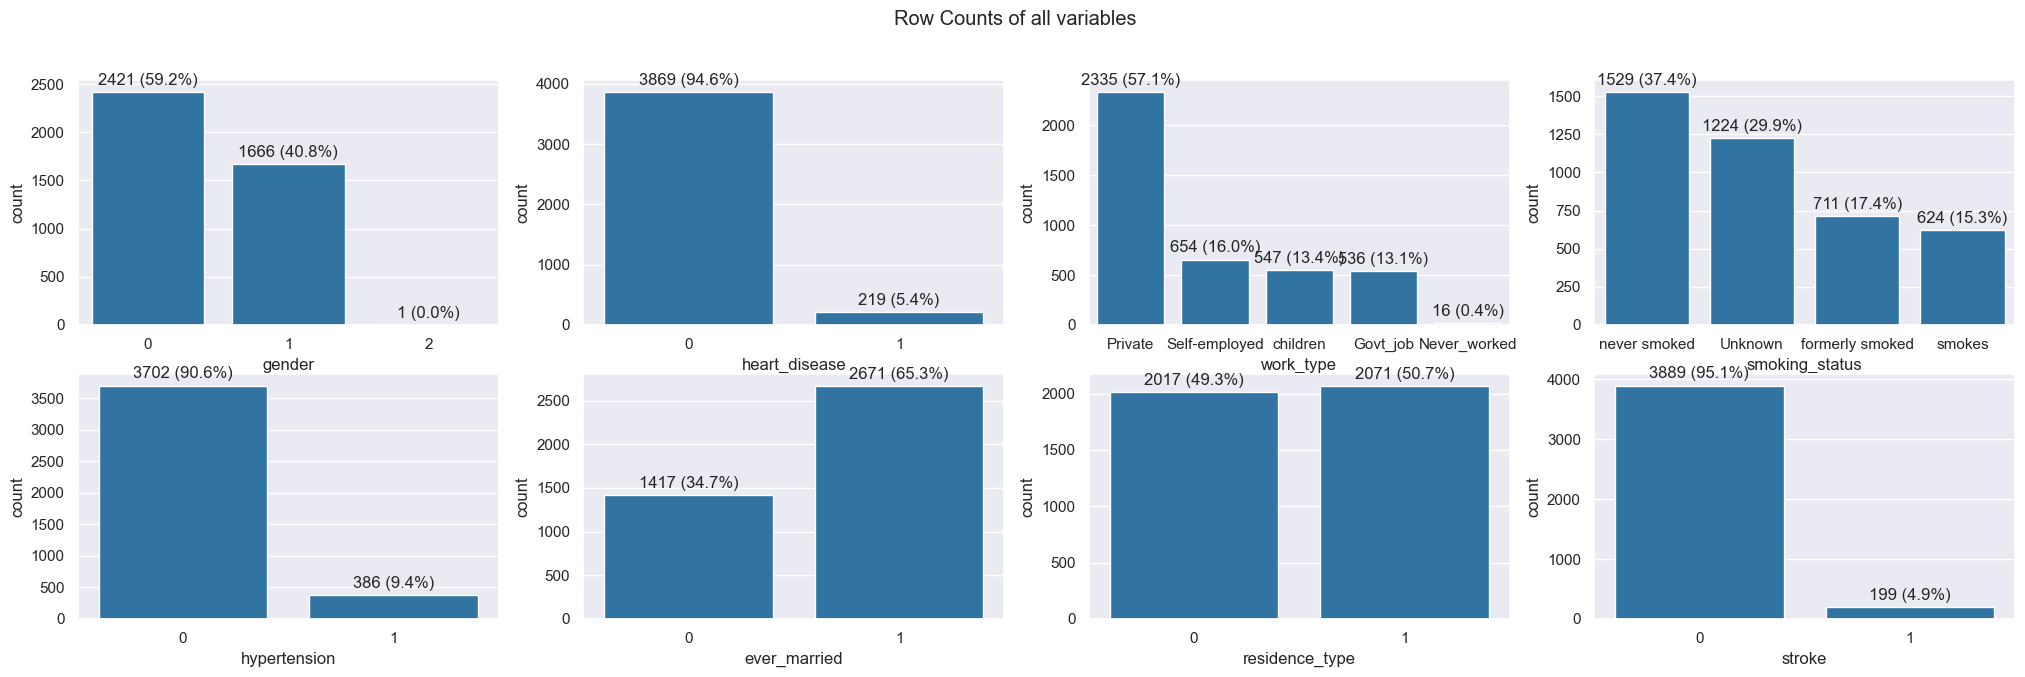

In [33]:
_, ax = plt.subplots(2, 4, figsize = (25, 7))

for i, column in enumerate([*categorical_variable_space, 'stroke']):
    row = i % 2
    col = i // 2
    sns.barplot(data = train_data[column].value_counts(), ax = ax[row][col])
    
    for p in ax[row][col].patches:
        height = p.get_height()
        ax[row][col].annotate(f'{int(height)} ({100 * int(height) / train_data.stroke.count():.1f}%)', 
                                xy=(p.get_x() + p.get_width() / 2, height),
                                xytext=(0, 3),  # 3 points vertical offset
                                textcoords="offset points",
                                ha='center', va='bottom')

plt.suptitle('Row Counts of all variables');

Some interesting points here. Firstly, there is only one person who has the gender "Other", and since 1 instance is not enough to create a valuable rule around it - this instance will be dropped. Secondly, the categories are mostly very unequal - for some it does make sense (like for `heart_disease` & `hypertension`) but for some this might indicate some inherent sampling bias, because there are roughly 20% more men than women, around 60% of all instances are "Private" employees (work in the private sector) and there are nearly have more married people than not married people. This can create a problem for the model as it won't be able to accurately represent some of these subgroups. Lastly, while it would make sense to remove the rows that have "Never_worked" as it only pertains to 0.4% of the dataset, let's first take a look further.

In [34]:
train_data = train_data[train_data['gender'] != 2]
validation_data = validation_data[validation_data['gender'] != 2]
test_data = test_data[test_data['gender'] != 2]
validation_data = validation_data[validation_data['gender'] != 2]
print(f"New row count: {train_data.stroke.count()}")

New row count: 4087


In [35]:
for value in set(train_data['work_type']):
    print(f"Average age of {value} people: {train_data[train_data['work_type'] == value]['age'].mean():.2f}")
train_data[train_data['work_type'] == 'Never_worked']

Average age of Never_worked people: 15.81
Average age of Private people: 45.42
Average age of children people: 6.85
Average age of Self-employed people: 60.05
Average age of Govt_job people: 50.80


,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke
id,,,,,,,,,,,
34900,1,13.0,0,0,0,Never_worked,1,85.08,14.6,Unknown,0
11702,0,18.0,0,0,0,Never_worked,1,82.36,22.7,Unknown,0
28461,1,15.0,0,0,0,Never_worked,0,79.59,28.4,Unknown,0
56986,1,17.0,0,0,0,Never_worked,1,113.25,23.4,never smoked,0
58652,0,16.0,0,0,0,Never_worked,0,68.27,20.4,never smoked,0
46136,1,14.0,0,0,0,Never_worked,0,161.28,19.1,Unknown,0
13960,0,18.0,0,0,0,Never_worked,1,97.65,21.5,Unknown,0
18605,0,17.0,0,0,0,Never_worked,1,78.08,44.9,never smoked,0
13948,0,19.0,0,0,0,Never_worked,1,86.96,25.8,never smoked,0


All of the people that have "Never_worked" are teenagers - which only makes sense and it would be illogical to remove these instances, because all `Never_worked` people have mostly `Never smoked` or have `Unknown` smoking status and thus did not have a stroke. The same thing goes for children - their average age is 6 and only a handful of them have had strokes.

If we drill down a bit, we can see two things: 
1. There are very few rows with age less than 18 (children & teens).
2. Before the age of around 38 - strokes are very rare. This is a good heuristic to learn before we create the model(s)

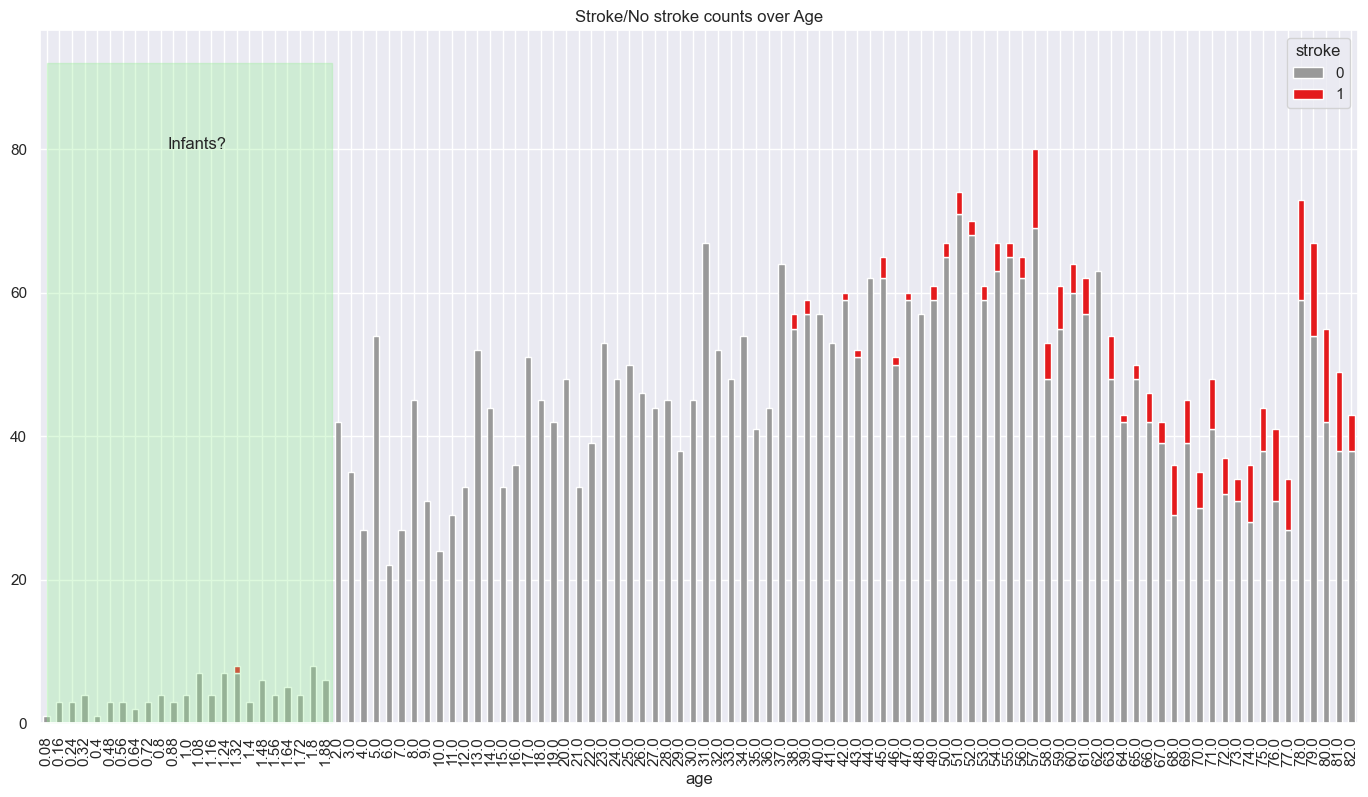

In [36]:
pivot_table = train_data.pivot_table(index='age', columns='stroke', aggfunc='size', fill_value=0)
pivot_table.plot(kind='bar', stacked=True, figsize=(17, 9), colormap='Set1_r')

y = [0, train_data['age'].max()+10]
plt.fill_betweenx(y, x1=0, x2=22.5, color='lightgreen', alpha=0.3);
plt.text(s = 'Infants?', x = 9.5, y = 80)
plt.title('Stroke/No stroke counts over Age');

Now let's quickly also look at the numerical variables - how do the correlate with one another and with regard to the `stroke` variable.

<Figure size 1000x800 with 0 Axes>

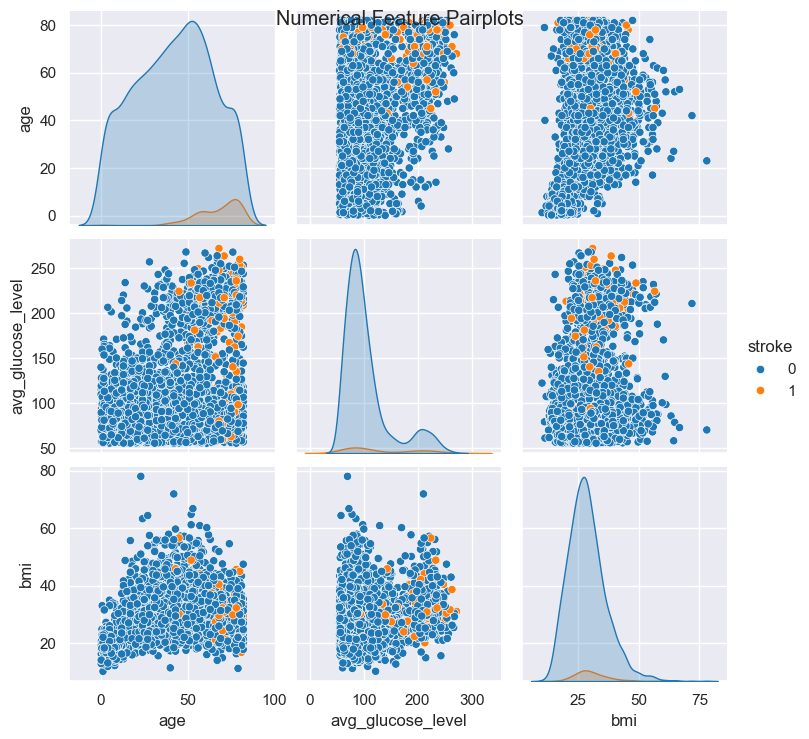

In [37]:
plt.figure(figsize = (10, 8))
pairplot = sns.pairplot(train_data[['stroke', *numerical_variable_space]],
                hue = 'stroke');
plt.suptitle('Numerical Feature Pairplots');
plt.show();

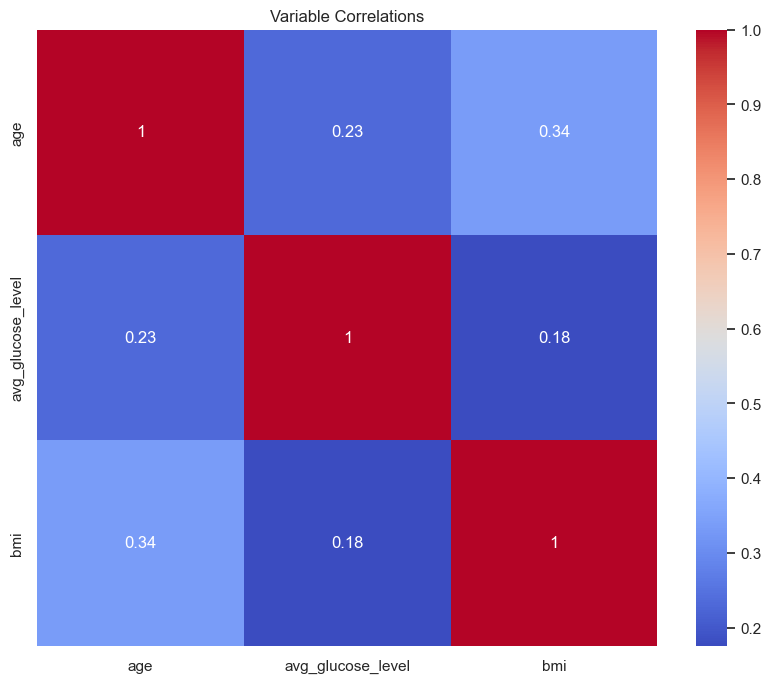

In [38]:
plt.figure(figsize = (10, 8))
correlation_matrix = train_data[numerical_variable_space].corr()
sns.heatmap(correlation_matrix, cmap="coolwarm", annot=True)
plt.title('Variable Correlations');
plt.show();

Well, one thing's for sure - we don't have multicollinearity between the numerical variables. Also, if we look at the PairPlot, we can see that strokes happen more frequently to people that are older (one thing we got to know earlier). Strokes also seem to be a bit more frequent for people with higher `average glucose levels`. Lastly, at least from the graphs BMI does not really have anything to do with it (as far as the chart goes).

What if we split these numerical variables down by the categorical variables?

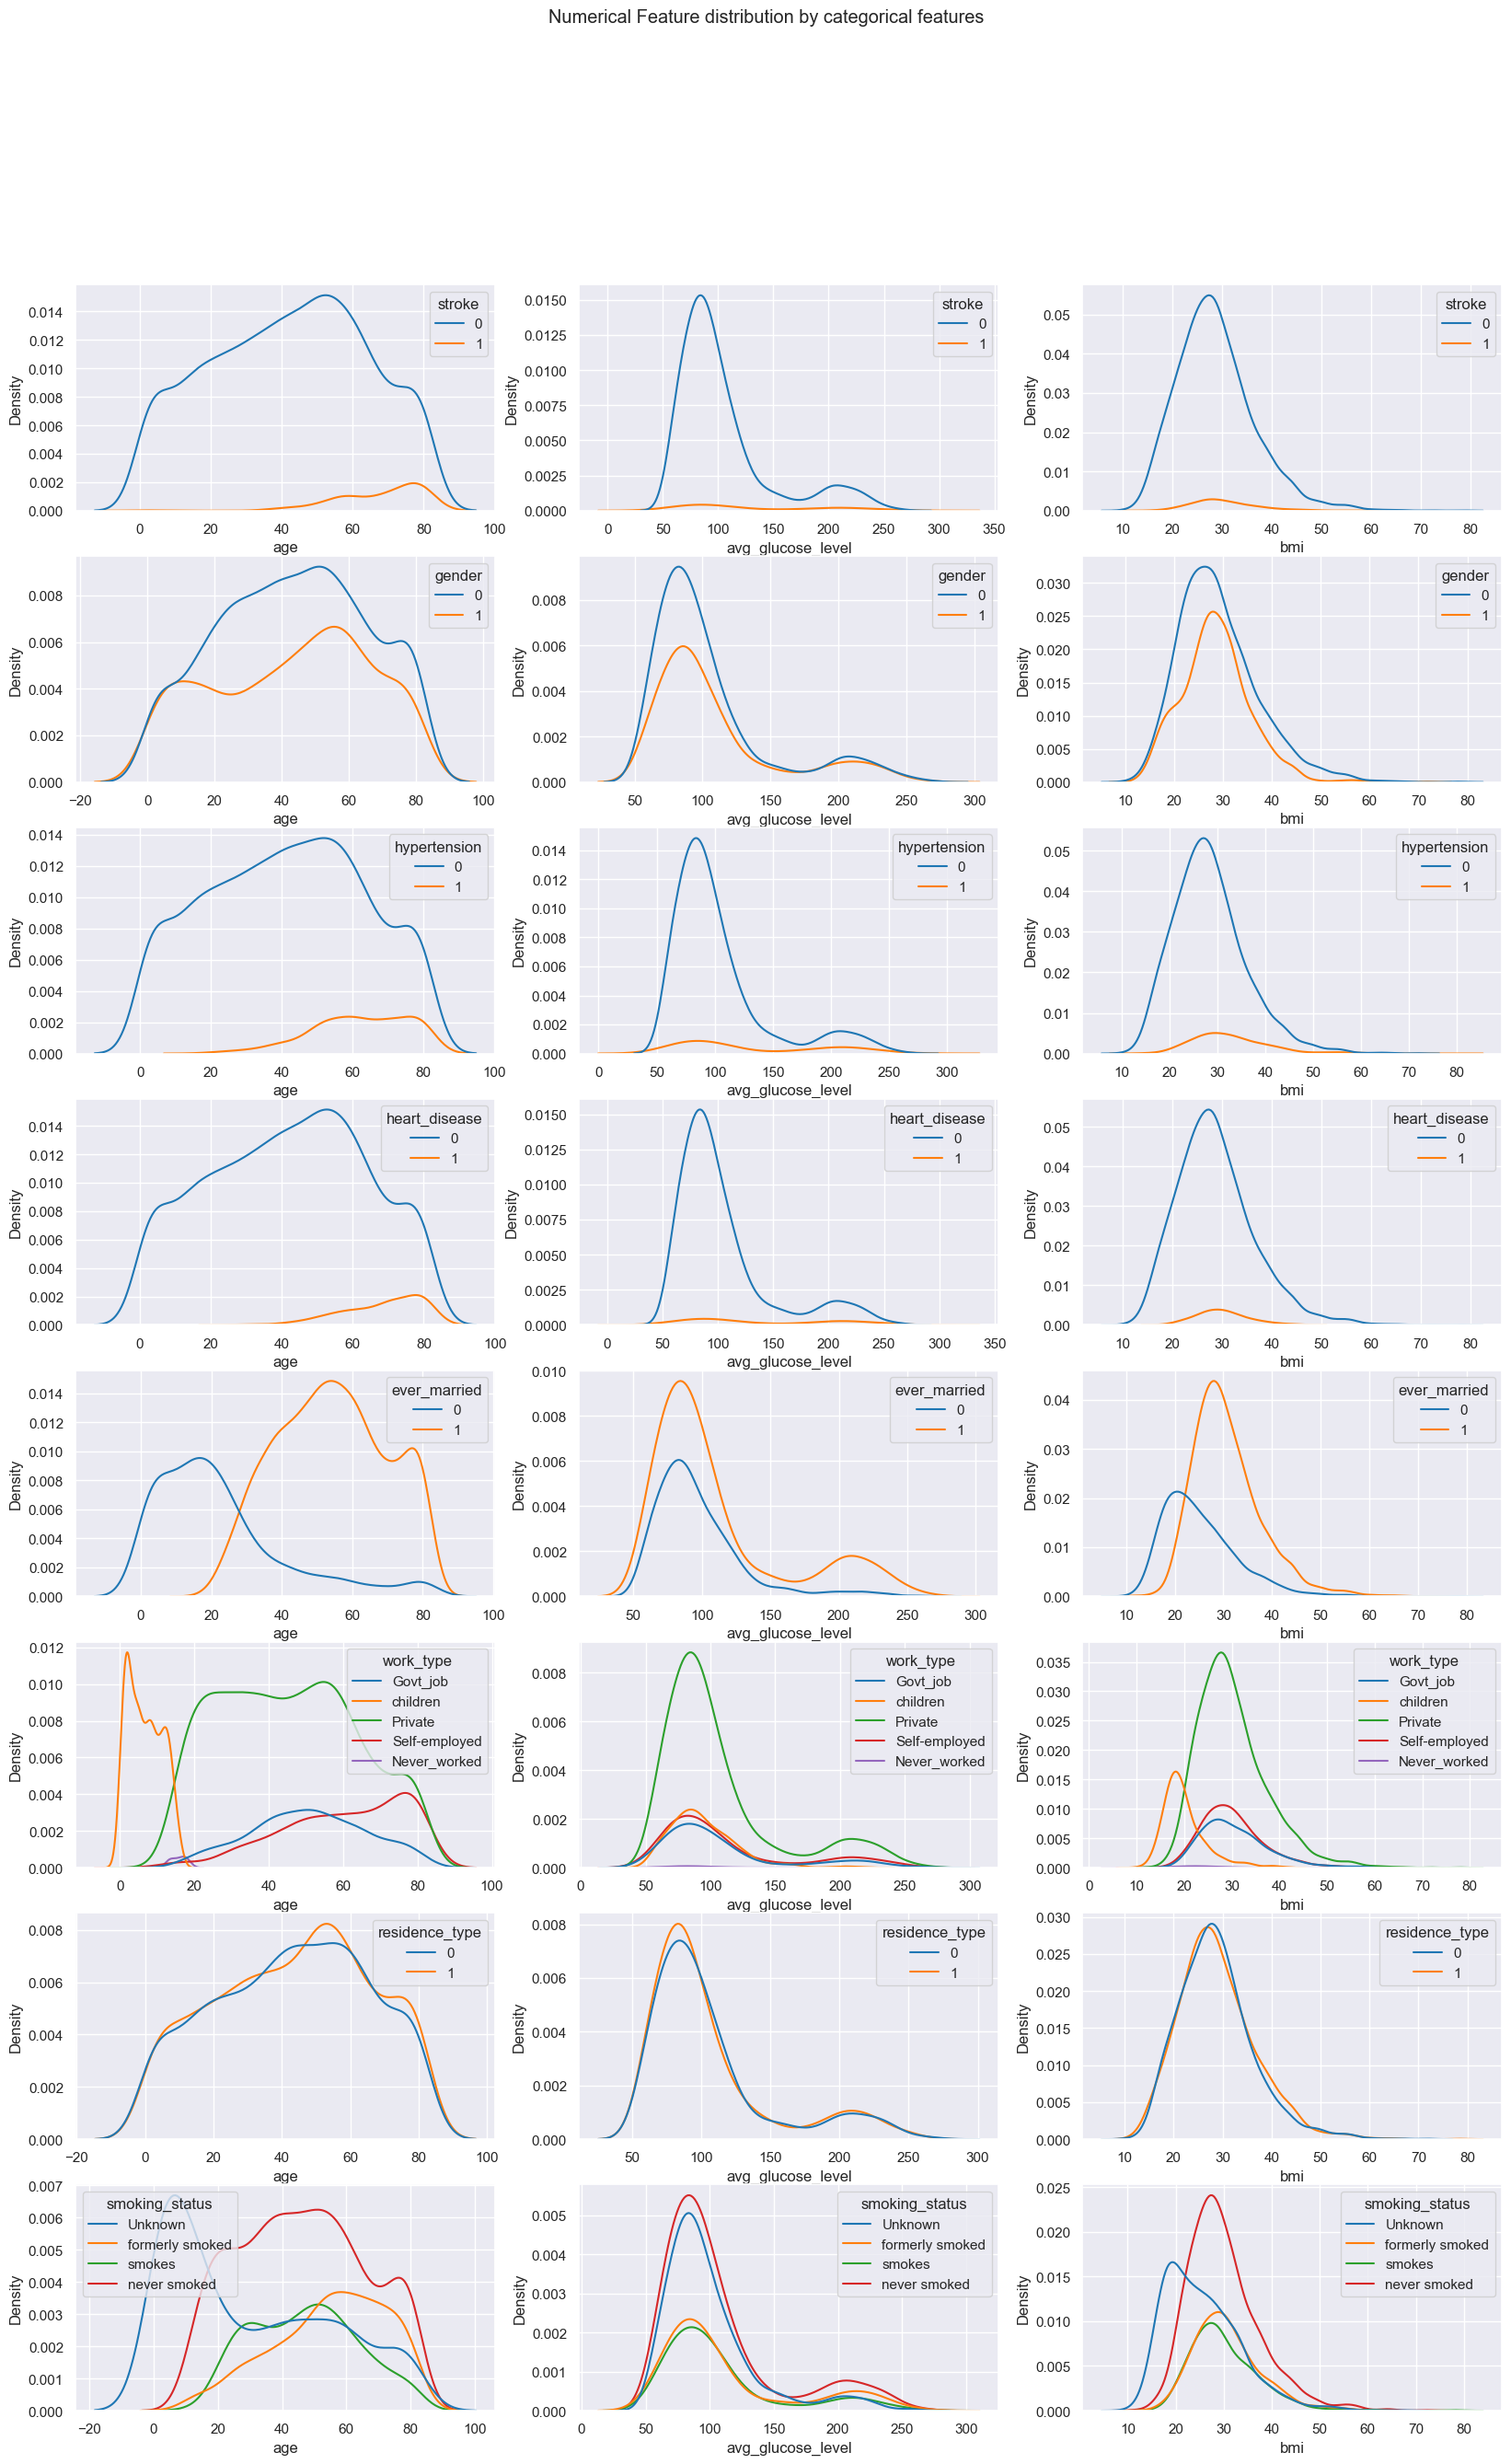

In [39]:
_, ax = plt.subplots(8, 3, figsize = (20, 30))

for j, row in enumerate(['stroke', *categorical_variable_space]):
    for i, column in enumerate(numerical_variable_space):
        sns.kdeplot(train_data, x = column, hue = row, ax = ax[j][i])

plt.suptitle("Numerical Feature distribution by categorical features");

There are some very interesting findings in this actually:
* We have relatively a wide range of ages in the dataset, and in terms of BMI & Glucose levels, we can see that the distribution is abit skewed to the right with the median landing somewhere around 80. This means that on average our training dataset is very healthy. although there is a bump for glucose levels at somewhere around 210.
* Never married people seem to have a bit less BMI (but this might be just highly correlated with age). Same thing goes for `children` and `bmi`. 
* Smoking people are relatively younger than formerly smoking people (just logical, I'd say).
* `Hypertension` & `heart_disease` seems to highly increase with age.

Nothing really groundbreaking - let's move on to how the categories themselves are distributed against `stroke` - `not stroke`.

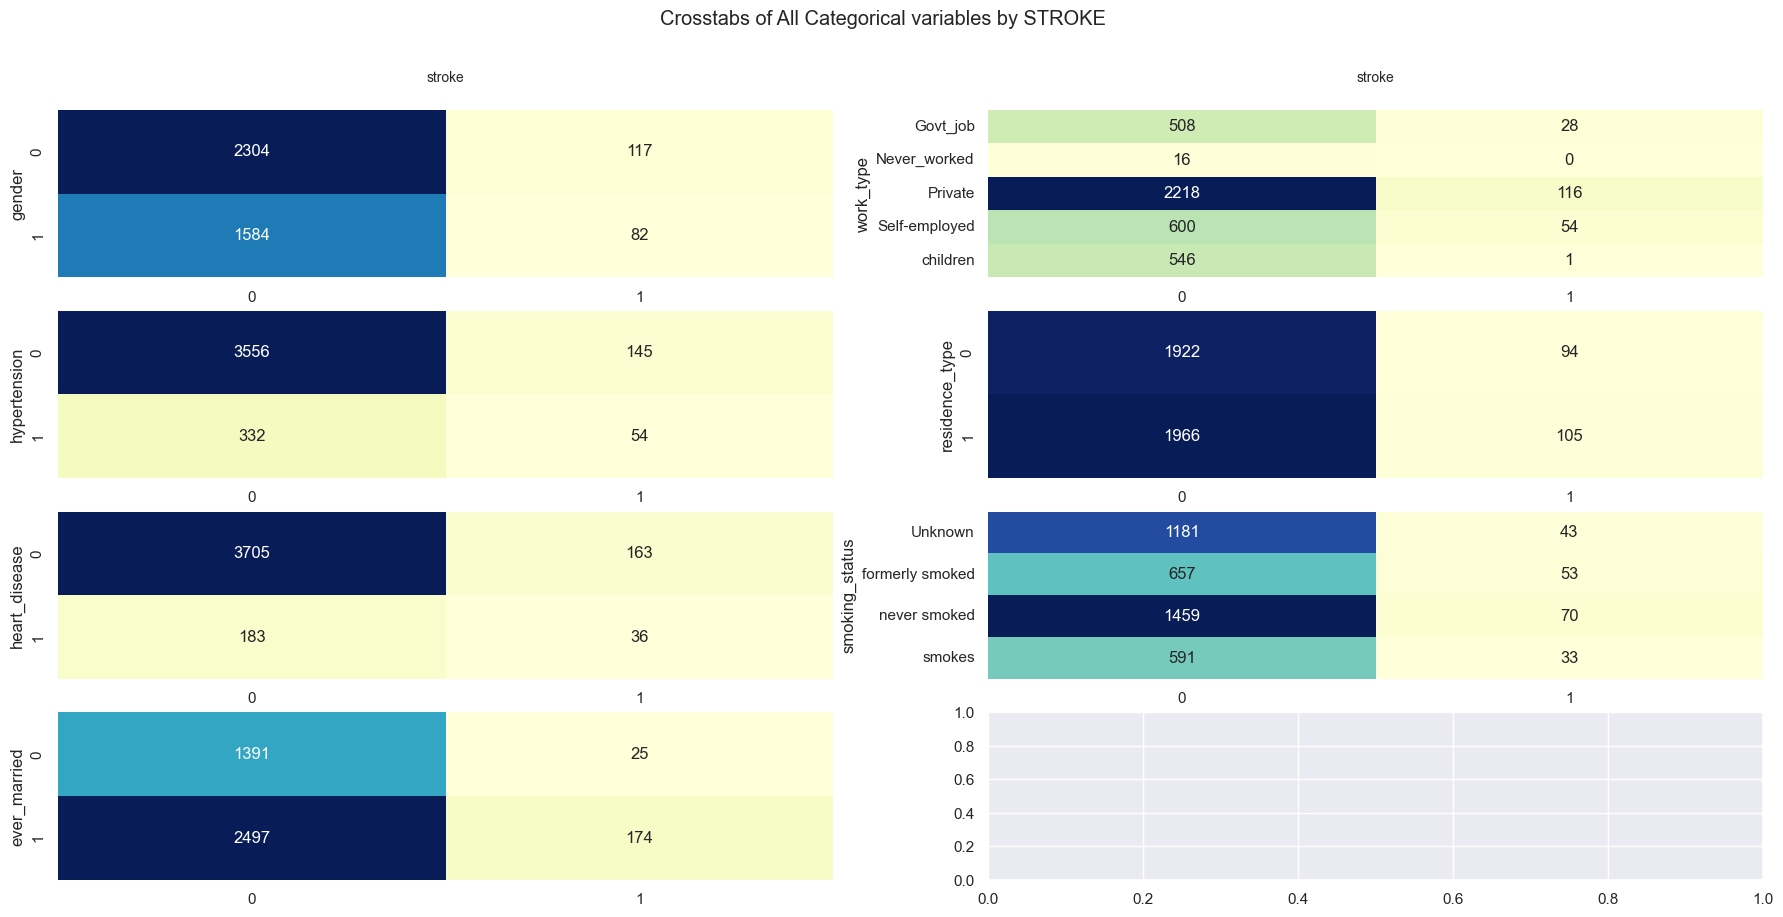

In [40]:
fig, ax = plt.subplots(4, 2, figsize = (22, 10))

for i, col in enumerate([*categorical_variable_space]):

    column = i % 4
    row = i // 4

    ct = pd.crosstab(train_data[col], train_data['stroke'])
    sns.heatmap(ct, annot=True, fmt='d', cmap='YlGnBu', cbar=False, ax = ax[column][row])
    
    # Remove default x-axis label
    ax[column][row].set_xlabel('')

    if column == 0:
        # Add custom label at the top
        ax[column][row].set_xlabel('stroke', labelpad=20, loc='center')
        ax[column][row].xaxis.set_label_position('top')
        ax[column][row].xaxis.label.set_fontsize(10)

fig.suptitle('Crosstabs of All Categorical variables by STROKE')
plt.show()

Well this is quite interesting now. Running through this quickly we can see:
1. About the same percentage of both genders have the same affinity towards strokes.
2. Most strokes (87%) happen to people that do not have hypertension and and heart_disease.
3. Never married people have slightly more people (percentage-wise) that do not get strokes.
4. Only 1 child has had a stroke - very likely no children get strokes then.
5. 9 % of self employed people have had strokes and 5% of Private sector employees have had strokes too.
6. Residence_type seems to not have a difference on the likelihood of there being a stroke.
7. 7.5% of previously smoked people have had strokes, whereas only 3.513% - have not. So you could say that smoking kills, but you also need to take into account that formerly_smoked people are much older on average than people who have "Unknown" as their smoking_status.

We can also quickly take a look at the means and medians of each numerical-categorical variable combination.

In [41]:
for category in categorical_variable_space:
    print(f'{category}')
    for numeric_variable in numerical_variable_space:
        for value in train_data[category].unique():
            filtered_data = train_data[train_data[category] == value]
            print(f'Value : {value} {numeric_variable} mean: {filtered_data[numeric_variable].mean():.2f}, median: {filtered_data[numeric_variable].median():.2f}')
        print('\n')
print('\n')

gender
Value : 1 age mean: 42.91, median: 46.00
Value : 0 age mean: 43.38, median: 44.00


Value : 1 avg_glucose_level mean: 108.69, median: 93.26
Value : 0 avg_glucose_level mean: 103.50, median: 90.29


Value : 1 bmi mean: 28.47, median: 28.20
Value : 0 bmi mean: 29.01, median: 27.80


hypertension
Value : 0 age mean: 41.20, median: 42.00
Value : 1 age mean: 62.28, median: 63.00


Value : 0 avg_glucose_level mean: 102.91, median: 90.55
Value : 1 avg_glucose_level mean: 131.57, median: 106.09


Value : 0 bmi mean: 28.41, median: 27.60
Value : 1 bmi mean: 32.65, median: 31.25


heart_disease
Value : 0 age mean: 41.75, median: 43.00
Value : 1 age mean: 68.54, median: 71.00


Value : 0 avg_glucose_level mean: 103.72, median: 90.72
Value : 1 avg_glucose_level mean: 139.19, median: 109.78


Value : 0 bmi mean: 28.73, median: 27.80
Value : 1 bmi mean: 30.02, median: 29.60


ever_married
Value : 1 age mean: 54.25, median: 54.00
Value : 0 age mean: 22.34, median: 18.00


Value : 1 avg_glucose

From these we can raise a few hypotheses to test

Hypotheses to test:
* Are Hypertension-affected clients on average older than non-affected ones? Have higher avg_glucose_level on average?
* Do people that have married at least once previously have higher mean glucose levels on average than single people? What about BMI?
* Is there a statistically significant difference in average glucose level between Govt_job and Private employees?

Lastly, let's look at the Associations between the categorical variables (via the Cramers V):

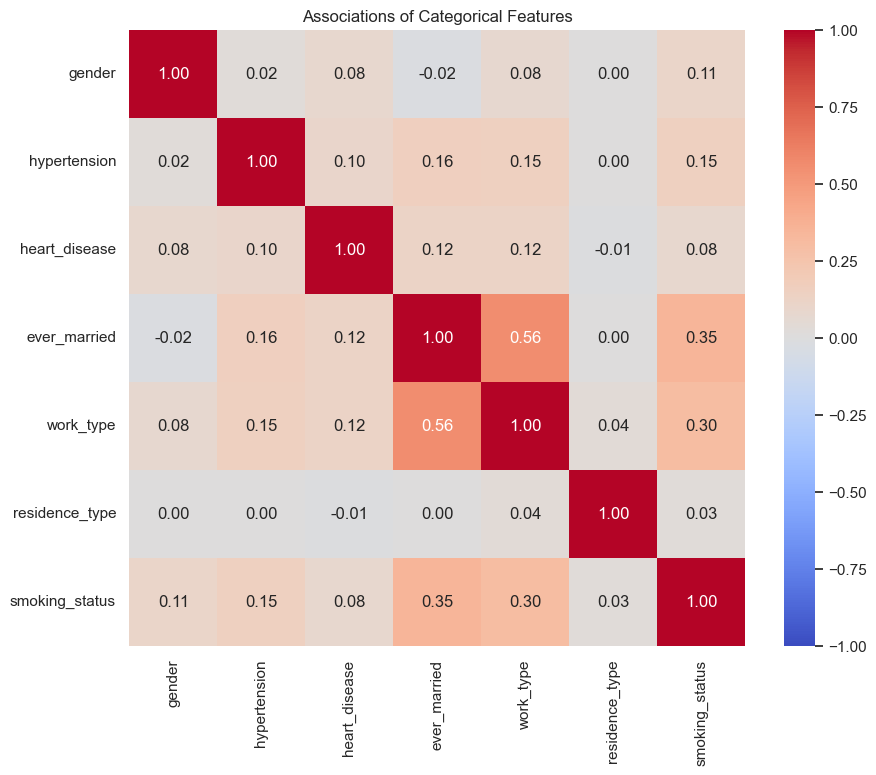

In [42]:
associations(train_data[categorical_variable_space], cmap='coolwarm', figsize=(10, 8), title = 'Associations of Categorical Features');

There seems to be no categorical variables that are very much associated (meaning "moving" in the same direction). Although, smoking_status seems to be somewhat correlated with ever_married (I guess married people are more inclined to smoke?) and work_type. And work_type with ever_married as well. However, since both of these variables are multi-value variables, it's hard to trust these values.

### Regression on BMI

Lastly, let's look at how many Null values we have in the dataset.

In [43]:
train_data.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
residence_type         0
avg_glucose_level      0
bmi                  156
smoking_status         0
stroke                 0
dtype: int64

We can see that there are some BMI values that are missing. However, what if we instantiated these values from the other variables via a regression in order to not miss these data points? That's what we will do next. Let's first take a look at the distribution of the BMI value

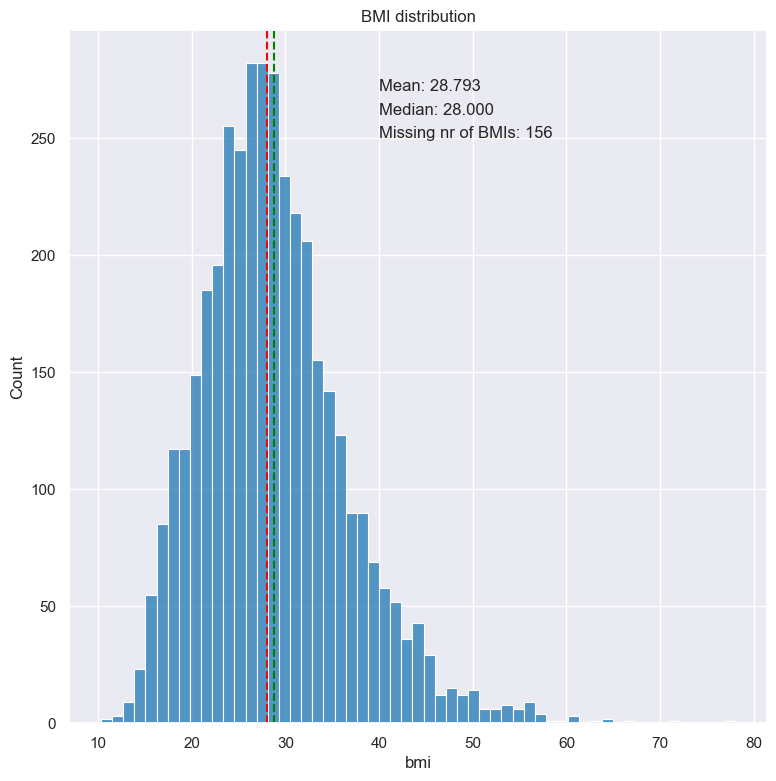

In [44]:
train_data['bmi'] = train_data['bmi'].replace(0, np.nan)

_ = plt.figure(figsize = (9, 9))
sns.histplot(data = train_data['bmi'])
plt.axvline(x = train_data['bmi'].mean(), color = 'g', linestyle = '--')
plt.axvline(x = train_data['bmi'].median(), color = 'r', linestyle = '--')
plt.text(s = f"Mean: {train_data['bmi'].mean():.3f}", x = 40, y = 270)
plt.text(s = f"Median: {train_data['bmi'].median():.3f}", x = 40, y = 260)
plt.text(s = f"Missing nr of BMIs: {train_data['bmi'].isnull().sum()}", x = 40, y = 250)
plt.title('BMI distribution');

If we were to use mean-imputing or median-imputing we would say that the value should be around 28. But let's proceed with regression imputation. It will be interesting to see how the distribution would change once we do so. But first - prepare our training and testing datasets.


In [45]:
BMI_level = train_data['bmi']
explanatory_variables = [*categorical_variable_space, *['age', 'avg_glucose_level']]

bmi_prediction_dataset = train_data.copy().dropna()

bmi_prediction_train, bmi_prediction_test, = train_test_split(bmi_prediction_dataset,
                                                                test_size=0.2,
                                                                random_state=12)

bmi_prediction_train = fn.filter_error_checker(bmi_prediction_train)
bmi_prediction_test = fn.filter_error_checker(bmi_prediction_test)

First up - it's the standard Gradient Boosting Regressor. We will also be optimizing for the Mean Absolute Error, because we want to get the closest possible values to the real ones as we can.

In [46]:
preprocessor = ColumnTransformer(
                    [('multi-categories', OneHotEncoder(dtype = 'int', sparse_output=False), multi_categories)],
                    remainder = StandardScaler(), verbose_feature_names_out=False)

standard_pipeline = Pipeline(steps = [
    ('preprocessor', preprocessor),
])

gradient_boosting_regression = make_pipeline(standard_pipeline, GradientBoostingRegressor(random_state=12))

gb_model = gradient_boosting_regression.fit(bmi_prediction_train[explanatory_variables], bmi_prediction_train['bmi'])

test_predictions = gb_model.predict(bmi_prediction_test[explanatory_variables])

fn.regression_performance_calculator(bmi_prediction_test['bmi'], test_predictions, 'regression')

Mean Absolute Error (MAE): 4.79
Mean Squared Error (MSE): 41.24
Root Mean Squared Error (RMSE): 6.42
R-squared (R²): 0.26


Decent performance, but I reckon we can go better with the XGBoost regressor:

In [47]:
xgboost_regression = make_pipeline(standard_pipeline, XGBRegressor(objective='reg:absoluteerror', random_state=12))

xgb_model = xgboost_regression.fit(bmi_prediction_train[explanatory_variables], bmi_prediction_train['bmi'])

test_predictions = xgb_model.predict(bmi_prediction_test[explanatory_variables])

fn.regression_performance_calculator(bmi_prediction_test['bmi'], test_predictions, 'regression')

Mean Absolute Error (MAE): 4.76
Mean Squared Error (MSE): 41.97
Root Mean Squared Error (RMSE): 6.48
R-squared (R²): 0.25


It's seems as though XGBoost performed marginaly better, so let's go with this model to fill out the BMI missing values.

In [48]:
data_for_imputation = train_data[train_data['bmi'].isna()][explanatory_variables]
data_for_imputation_validation = validation_data[validation_data['bmi'].isna()][explanatory_variables]
data_for_imputation_test = test_data[test_data['bmi'].isna()][explanatory_variables]

train_data.loc[train_data['bmi'].isna(), 'bmi'] = xgb_model.predict(data_for_imputation)
validation_data.loc[validation_data['bmi'].isna(), 'bmi'] = xgb_model.predict(data_for_imputation_validation)
test_data.loc[test_data['bmi'].isna(), 'bmi'] = xgb_model.predict(data_for_imputation_test)

And now we shouldn't have any more missing values. Let's also check in on our histogram.

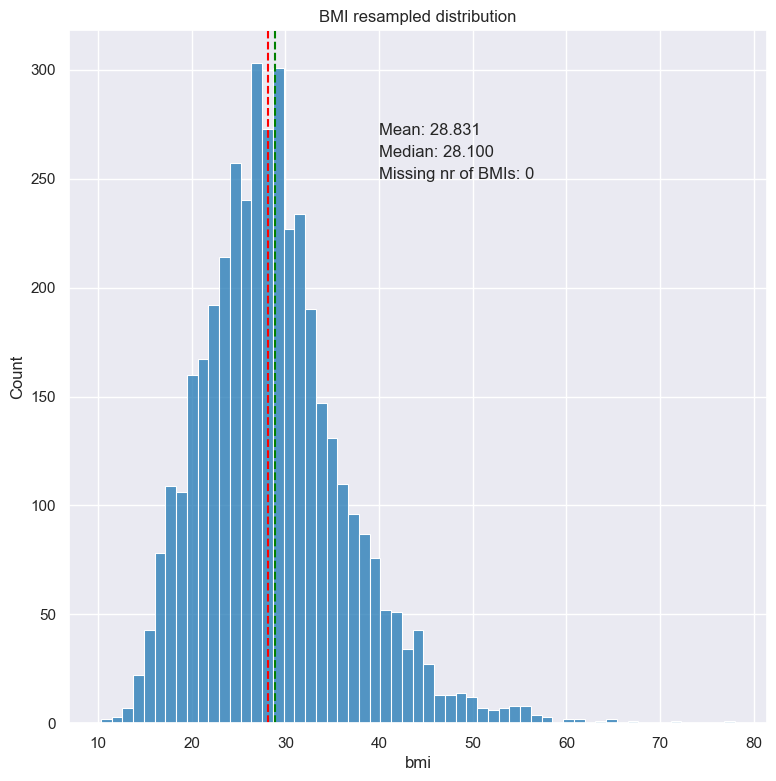

In [49]:
train_data['bmi'] = train_data['bmi'].replace(0, np.nan)
test_data['bmi'] = test_data['bmi'].replace(0, np.nan)

_ = plt.figure(figsize = (9, 9))
sns.histplot(data = train_data['bmi'])
plt.axvline(x = train_data['bmi'].mean(), color = 'g', linestyle = '--')
plt.axvline(x = train_data['bmi'].median(), color = 'r', linestyle = '--')
plt.text(s = f"Mean: {train_data['bmi'].mean():.3f}", x = 40, y = 270)
plt.text(s = f"Median: {train_data['bmi'].median():.3f}", x = 40, y = 260)
plt.text(s = f"Missing nr of BMIs: {train_data['bmi'].isnull().sum()}", x = 40, y = 250)
plt.title('BMI resampled distribution');

And we can see that the missing values were placed around the mean/median values and haven't shifted the graph all that much - something which we expected.

### Missing Data Imputation

Now what about the Target variable? Let's test out whether we have an even amount of instances of people having strokes and not having strokes. 

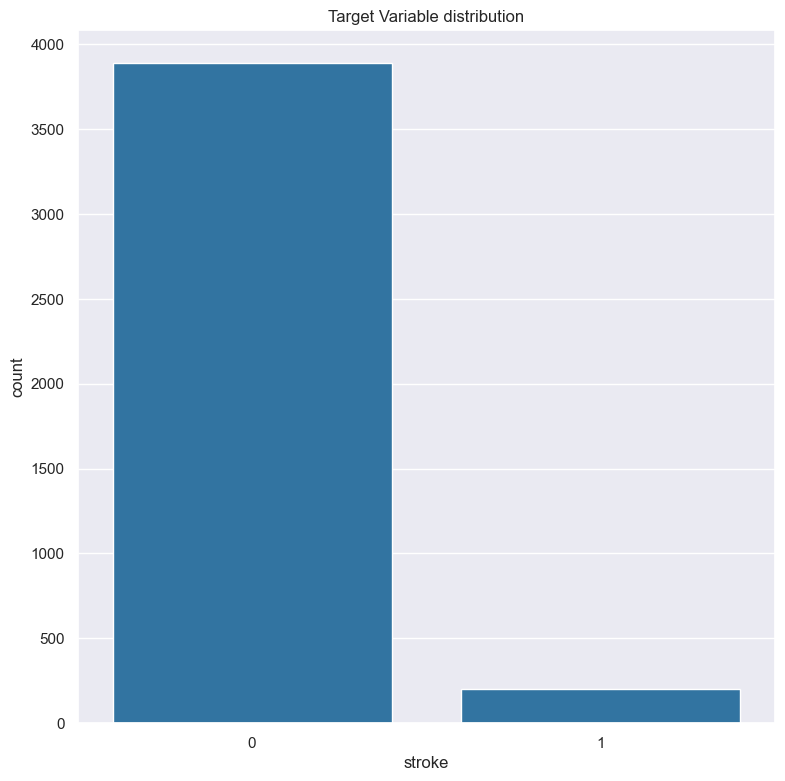

In [50]:
_ = plt.figure(figsize = (9, 9))
sns.barplot(data = train_data[target_variable_column].value_counts())
plt.title('Target Variable distribution');

Well, I guess it makes sense - you would expect way more people NOT to have any strokes. However, this poses a bit of a headscratching problem from the machine learning point of view - because this disallows for the model to easily pick up the nuances between the two groups - stroke and not stroke. Therefore, we will be performing Oversampling using SMOTE on the train_data dataframe to even out the instances between `stroke` and `not stroke`. But before that - let's create X and y dataframes for training, validation & testing. 

In [51]:
X_train = train_data[[*set(variable_space_columns) - set(target_variable_column)]]
y_train = train_data[target_variable_column]

X_val = validation_data[[*set(variable_space_columns) - set(target_variable_column)]]
y_val = validation_data[target_variable_column]

X_test = test_data[[*set(variable_space_columns) - set(target_variable_column)]]
y_test = test_data[target_variable_column]

In [52]:
smote = SMOTENC(categorical_features=[*set(variable_space_columns) - set(numerical_variable_space)], random_state=20)
# smote = SMOTE(random_state=20)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print(f"Explanatory Variable instance count: {X_train_resampled.shape[0]}\nTarget Variable instance count: {y_train_resampled.count()}")

c:\Users\KasparasRutkauskas\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\KasparasRutkauskas\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\KasparasRutkauskas\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\KasparasRutkauskas\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1026, in __init__
    self._execu

Explanatory Variable instance count: 7776
Target Variable instance count: 7776


After the resampling we can see that the number of instances has actually risend to 7776 - so is the number of strokes and non-strokes the same now? 

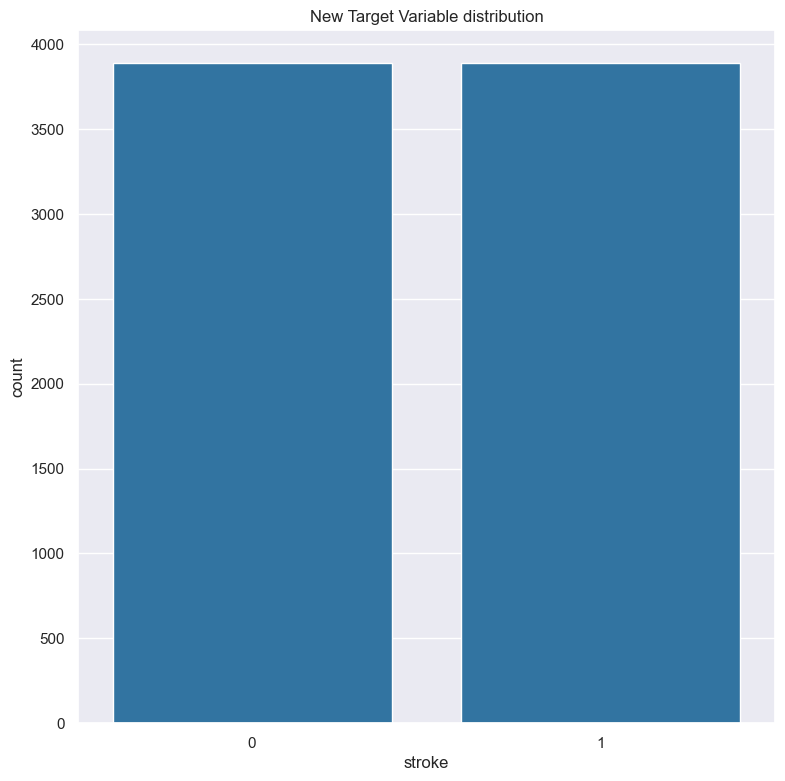

In [53]:
_ = plt.figure(figsize = (9, 9))
sns.barplot(data = y_train_resampled.value_counts())
plt.title('New Target Variable distribution');

Yes it is! I guess it makes sense, the oversampling just raised the number of instances in the `strokes` case to the number of instances in the `non-stroke` case. Let's also take a peek at whether it has significantly altered our distribution of numeric and categoric variables?

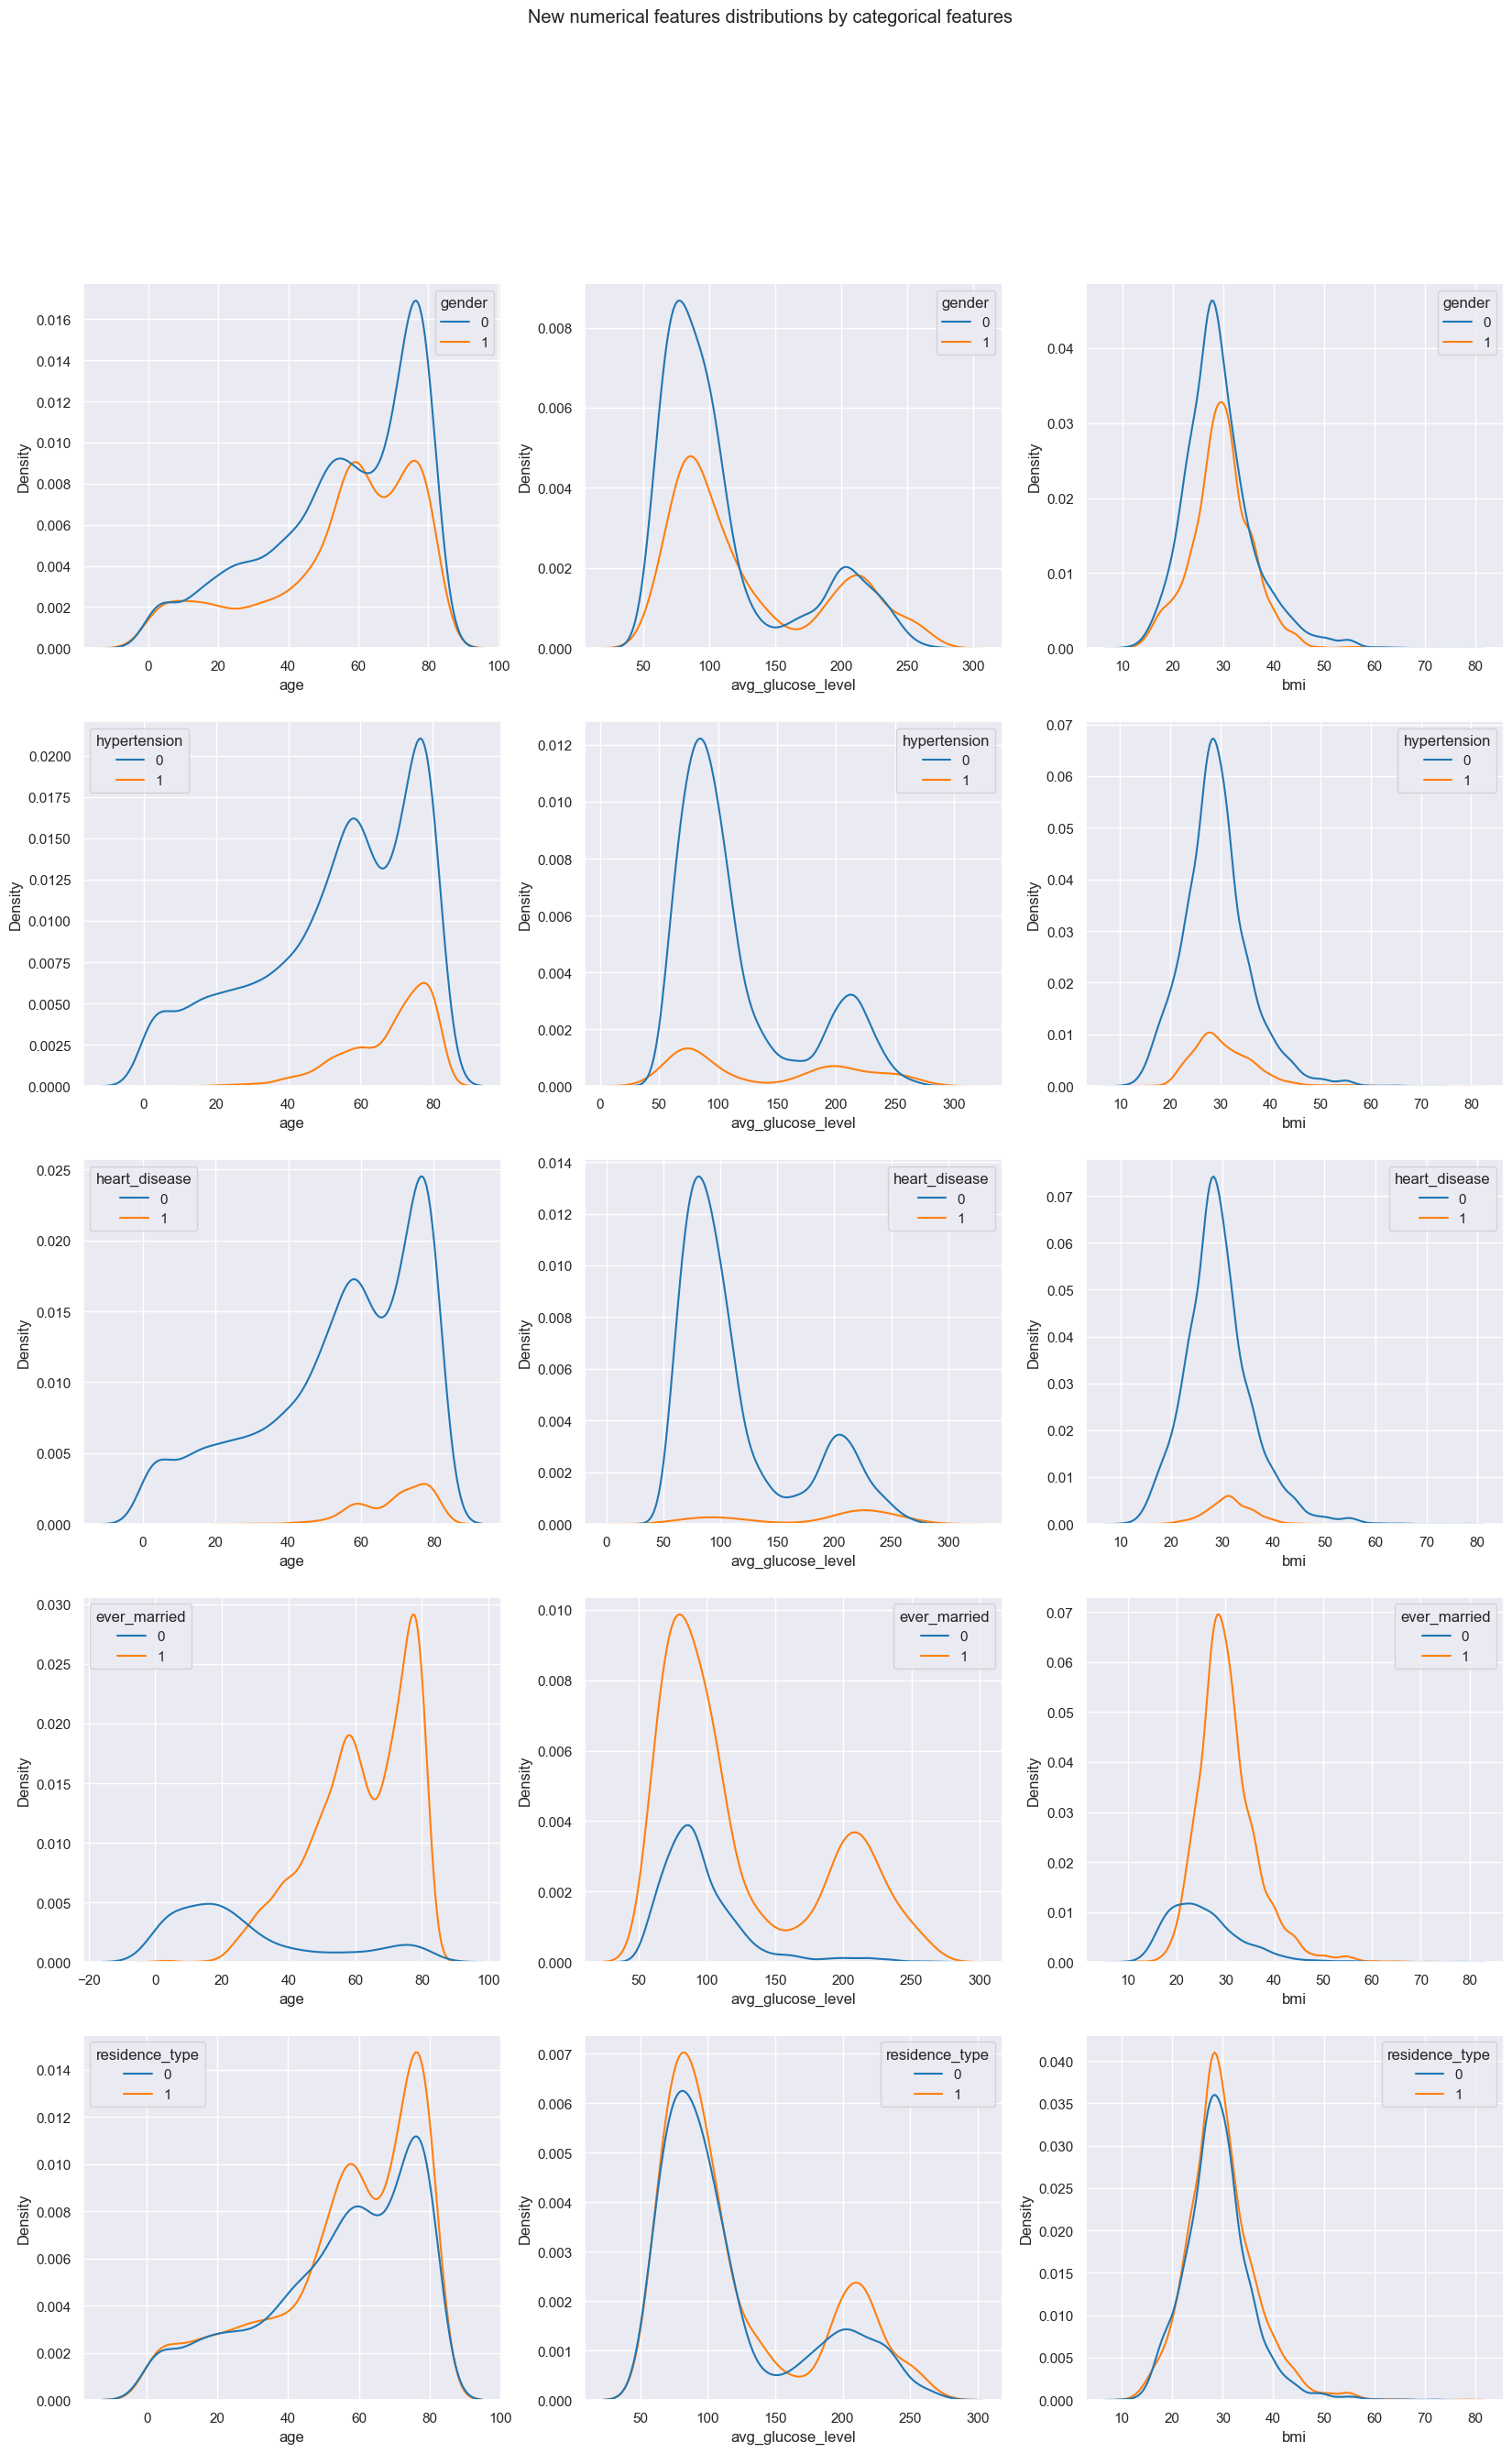

In [54]:
_, ax = plt.subplots(5, 3, figsize = (20, 30))

for j, row in enumerate(['gender', 'hypertension', 'heart_disease', 'ever_married', 'residence_type']):
    for i, column in enumerate(numerical_variable_space):
        # ax[j][i].text(x = 0, y = 0, s = f"{j}, {i}")
        sns.kdeplot(X_train_resampled, x = column, hue = row, ax = ax[j][i])
plt.suptitle('New numerical features distributions by categorical features');

Well there seems to have been some changes, but overall the tendencies has not changed - just more values in the graphs so they look pointier.

## Statistical Inference

Alright! Let's do some inference.
Hypotheses to test:
* Are Hypertension-affected clients on average older than non-affected ones? Have higher avg_glucose_level on average?
* Do people that have married at least once previously have higher mean glucose levels on average than single people? What about BMI?
* Is there a statistically significant difference in average glucose level between Govt_job and Private employees? What about age?

Our hypotheses for `hypertension`:

`H0` : hypertension_average_age - not_hypertension_average_age >= 0

`H1` : hypertension_average_age - not_hypertension_average_age < 0

Our hypotheses for `avg_glucose_level`:

`H0` : hypertension_average_glucose_levels - not_hypertension_average_glucose_levels >= 0

`H1` : hypertension_average_glucose_levels - not_hypertension_average_glucose_levels < 0

Significance Level: `5%`

In [55]:
affected = train_data[train_data['hypertension'] == 1]['age'].values
non_affected = train_data[train_data['hypertension'] == 0]['age'].values

print(f"Average hypertension-affected age mean: {affected.mean()}")
print(f"Average not hypertension-affected age mean: {non_affected.mean()}")

ttest = stats.ttest_ind(affected, non_affected, alternative='greater')
print(f"P-value: {ttest.pvalue}\n")

affected = train_data[train_data['hypertension'] == 1]['avg_glucose_level'].values
non_affected = train_data[train_data['hypertension'] == 0]['avg_glucose_level'].values

print(f"Average hypertension-affected avg_glucose_level mean: {affected.mean()}")
print(f"Average not hypertension-affected avg_glucose_level mean: {non_affected.mean()}")

ttest = stats.ttest_ind(affected, non_affected, alternative='greater')
print(f"P-value: {ttest.pvalue}\n")

Average hypertension-affected age mean: 62.284974093264246
Average not hypertension-affected age mean: 41.198832747905975
P-value: 2.765028367950764e-71

Average hypertension-affected avg_glucose_level mean: 131.57349740932642
Average not hypertension-affected avg_glucose_level mean: 102.91017292623617
P-value: 2.5040177093211803e-33



Both seem to be statistically significant - hypertension-affected people are older and have higher average glucose levels on average. Moving on to statement 2

Do people that have married at least once previously have higher mean `glucose` levels on average than single people? What about `BMI`?

Our hypotheses for `glucose`:

`H0` : married_glucose_levels - single_glucose_levels >= 0

`H1` : married_glucose_levels - single_glucose_levels < 0

Our hypotheses for `BMI`:

`H0` : married_bmi - single_bmi >= 0

`H1` : married_bmi - single_bmi < 0

Significance Level: `5%`

In [56]:
married = train_data[train_data['ever_married'] == 1]
single = train_data[train_data['ever_married'] == 0]

print(f"Average married average glucose levels mean: {married['avg_glucose_level'].values.mean()}")
print(f"Average single average glucose levels mean: {single['avg_glucose_level'].values.mean()}")

ttest = stats.ttest_ind(married['avg_glucose_level'].values, single['avg_glucose_level'].values, alternative='greater')
print(f"P-value: {ttest.pvalue}\n")

print(f"Average married BMI mean: {married['bmi'].values.mean()}")
print(f"Average single BMI mean: {single['bmi'].values.mean()}")

ttest = stats.ttest_ind(married['bmi'].values, single['bmi'].values, alternative='greater')
print(f"P-value: {ttest.pvalue}\n")

Average married average glucose levels mean: 110.62735305129166
Average single average glucose levels mean: 96.16685028248587
P-value: 5.698260173318713e-23

Average married BMI mean: 30.76633549257862
Average single BMI mean: 25.180109390161803
P-value: 3.910362315651143e-117



Again, both seem to be statistically true - married people have higher average glucose levels and BMIs than single people. But then again that could be related with a person's age and not marital status per se. Statement 3.

Is there a statistically significant difference in average glucose level between `Govt_job` and `Private` employees? What about `age`?

Our hypotheses for `glucose`:

`H0` : private_glucose_levels = govt_job_glucose_levels

`H1` : private_glucose_levels $\neq$ govt_job_glucose_levels

Our hypotheses for `age`:

`H0` : private_age = govt_job_age

`H1` : private_age $\neq$ govt_job_age

Significance Level: `5%`

In [57]:
private = train_data[train_data['work_type'] == 'Private']
govt_job = train_data[train_data['work_type'] == 'Govt_job']

print(f"Average Private average glucose levels mean: {private['avg_glucose_level'].mean()}")
print(f"Average Government Job average glucose levels mean: {govt_job['avg_glucose_level'].mean()}")

ttest = stats.ttest_ind(private['avg_glucose_level'].values, govt_job['avg_glucose_level'].values, alternative='two-sided')
print(f"P-value: {ttest.pvalue}\n")

print(f"Average Private age mean: {private['age'].mean()}")
print(f"Average Government Job age mean: {govt_job['age'].mean()}")

ttest = stats.ttest_ind(private['age'].values, govt_job['age'].values, alternative='two-sided')
print(f"P-value: {ttest.pvalue}\n")

Average Private average glucose levels mean: 106.31834618680377
Average Government Job average glucose levels mean: 107.66916044776119
P-value: 0.5422525726450724

Average Private age mean: 45.42373607540703
Average Government Job age mean: 50.79664179104478
P-value: 4.4621672158400135e-10



This time we have a different result - Private sector employees do not seem to have higher average glucose levels, but they do appear to be statistically significantly older - on average by almost 5 years. Statement 4.

Now that we have got everything taken care of - let's move to modelling.

## Modelling

Here's the fun bit. For this project we will be using three tree-based models for the prediction of which people will get strokes or not. This is more so that I would learn about these models rather than how effective they are in these particular instances - while we still hope they will be effective. But first, we will be using the standard_pipeline that we have previously built for the BMI predictions models - just because it utilized the variables the exact same way. Additionally, each model will be tuned so that it would prioritize ROC_AUC - just to get the balance between precision and recall correct.

**Gradient Boosting Classifier**

In [58]:
X_val_preprocessed = standard_pipeline.fit_transform(X_val)

gradientboosting_classifier = make_pipeline(standard_pipeline,
                                            GradientBoostingClassifier(random_state = 12))

gradientboosting_classifier.fit(X_train_resampled, y_train_resampled)

y_predictions = gradientboosting_classifier.predict(X_val)

fn.regression_performance_calculator(y_val, y_predictions, 'classifier')

Accuracy: 0.78
Precision: 0.15
Recall: 0.72
F1 score: 0.24


Looking at the performance of the base model against the validation dataset, we can already see that there is some potential - however, the precision is pretty low compared to the recall - this model is just racking everything up and not precisely getting the people in risk. What about the base version of the Extreme Boosting Classifier?

In [59]:
xgb_classifier = make_pipeline(standard_pipeline,
                          XGBClassifier(objective = 'binary:logistic', seed = 12,
                                        early_stopping_rounds = 10,
                                        eval_metric = 'auc'))


xgb_classifier.fit(X_train_resampled, y_train_resampled, xgbclassifier__eval_set=[(X_val_preprocessed, y_val)])

y_predictions = xgb_classifier.predict(X_val)

fn.regression_performance_calculator(y_val, y_predictions, 'classifier')

[0]	validation_0-auc:0.67597
[1]	validation_0-auc:0.69675
[2]	validation_0-auc:0.68840
[3]	validation_0-auc:0.69123
[4]	validation_0-auc:0.69679
[5]	validation_0-auc:0.71564
[6]	validation_0-auc:0.72914
[7]	validation_0-auc:0.73753
[8]	validation_0-auc:0.74132
[9]	validation_0-auc:0.73860
[10]	validation_0-auc:0.73700
[11]	validation_0-auc:0.73992
[12]	validation_0-auc:0.74387
[13]	validation_0-auc:0.73185
[14]	validation_0-auc:0.73576
[15]	validation_0-auc:0.73568
[16]	validation_0-auc:0.74045
[17]	validation_0-auc:0.74239
[18]	validation_0-auc:0.74280
[19]	validation_0-auc:0.73210
[20]	validation_0-auc:0.73280
[21]	validation_0-auc:0.73358
[22]	validation_0-auc:0.72971
Accuracy: 0.80
Precision: 0.17
Recall: 0.76
F1 score: 0.27


After 19 iterations, we see that the AUC lands somewhere around 0.7365, however, the model itself has not improved the predictive capabilities of the gradient boosting classifier. What about LGBM?

In [60]:
lightgbm_classifier = make_pipeline(standard_pipeline,
                        LGBMClassifier(
                                        objective = 'binary',
                                        seed = 12,
                                        boosting_type = 'gbdt',
                                        metric = 'auc'))


lightgbm_classifier.fit(X_train_resampled, y_train_resampled, lgbmclassifier__eval_set=[(X_val_preprocessed, y_val)])

y_predictions = lightgbm_classifier.predict(X_val)

fn.regression_performance_calculator(y_val, y_predictions, 'classifier')

[LightGBM] [Info] Number of positive: 3888, number of negative: 3888
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001657 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 796
[LightGBM] [Info] Number of data points in the train set: 7776, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Accuracy: 0.92
Precision: 0.21
Recall: 0.20
F1 score: 0.20


Now this is interesting, the base model of the lgbm classifier is much better in accuracy, but then suffers in precision and recall. This most likely is related with how the model is trained - the fact that it trains with l1/l2 regularization, it allows for much less overfitting. Let's try to get the best versions of these models.

# Cross Validation & Tuning

Each model will have a preset set of variables that can be updated to get the best possible version of the model to fit the underlying data. Each model will have 5 folds of 10 iterations for tuning. First up - it's the GradientBoostingClassifier

In [61]:
gradientboosting_classifier_param_distributions = {
    'gradientboostingclassifier__n_estimators': randint(50, 200),
    'gradientboostingclassifier__learning_rate': uniform(0.01, 0.3),
    'gradientboostingclassifier__max_depth': randint(3, 10),
    'gradientboostingclassifier__min_samples_split': randint(2, 20),
    'gradientboostingclassifier__min_samples_leaf': randint(1, 20),
    'gradientboostingclassifier__max_features': ['auto', 'sqrt', 'log2', None]
}

In [ ]:
# from sklearn.model_selection import RandomizedSearchCV

# def shorten_param(param_name : str) -> str:
#     """
#     Removes Unnecessary titles from the columns of a dataset (particularly for hyperparameter tuning results of models)
#     """

#     if "__" in param_name:
#         return param_name.rsplit("__", 1)[1]
#     return param_name

# def cross_validation_setup(type, model, param_dist, training_data, target_data, training_validation_dataset, target_validation_dataset, iterations : int = 10) -> pd.DataFrame:
    
#     """
#     Performs Cross Validation for given model, for given number of iterations on a specific training dataset & parameter distributions.
#     """

#     hyperparameter_search = RandomizedSearchCV(
#                                 model,
#                                 param_distributions=param_dist,
#                                 n_iter=iterations,
#                                 cv=5,
#                                 verbose=1,
#                                 scoring='roc_auc',
#                                 random_state=12,
#                                 n_jobs=-1
#                             )
#     if type == 'lgbmclassifier':
#         hyperparameter_search.fit(training_data, target_data, lgbmclassifier__eval_set=[(training_validation_dataset, target_validation_dataset)])
#     elif type == 'xgbclassifier':
#         hyperparameter_search.fit(training_data, target_data, xgbclassifier__eval_set=[(training_validation_dataset, target_validation_dataset)])
#     else:
#         hyperparameter_search.fit(training_data, target_data)
    
#     print(f"Best Model Hyperparameters: {hyperparameter_search.best_params_}")
#     print(f"Best Model ROC_AUC Score: {hyperparameter_search.best_score_}")

#     cv_results = pd.DataFrame(hyperparameter_search.cv_results_).rename(shorten_param, axis=1)

#     return hyperparameter_search.best_estimator_, cv_results

In [68]:
best_gradientboosting_classifier, cv_results = fn.cross_validation_setup('gbclassifier',
                          gradientboosting_classifier,
                          gradientboosting_classifier_param_distributions,
                          X_train_resampled,
                          y_train_resampled,
                          X_val_preprocessed,
                          y_val)

y_predictions_gb = best_gradientboosting_classifier.predict(X_val)
fn.regression_performance_calculator(y_val, y_predictions_gb, 'classifier')

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Model Hyperparameters: {'gradientboostingclassifier__learning_rate': 0.2114357935636008, 'gradientboostingclassifier__max_depth': 4, 'gradientboostingclassifier__max_features': None, 'gradientboostingclassifier__min_samples_leaf': 16, 'gradientboostingclassifier__min_samples_split': 3, 'gradientboostingclassifier__n_estimators': 106}
Best Model ROC_AUC Score: 0.9866059370987635
Accuracy: 0.92
Precision: 0.21
Recall: 0.20
F1 score: 0.20


These seem to be the best hyperparameters for the Gradient Boosting Classifier:
`learning_rate`: 0.13651733037376793,
`max_depth`: 9,
`max_features`: 'log2',
`min_samples_leaf`: 14,
`min_samples_split`: 5,
`n_estimators`: 180 

The best model's ROC_AUC seems to be `0.9866619613013041`. However, it seems a bit too overfitted. Let's check out the XGBoost Classifier

In [70]:
xgb_classifier_param_distributions = {
    'xgbclassifier__booster' : ['gbtree', 'gblinear', 'dart'],
    'xgbclassifier__n_estimators': [50, 100, 200, 300],
    'xgbclassifier__max_depth': [3, 5, 7, 9],
    'xgbclassifier__learning_rate': [0.01, 0.1, 0.2, 0.3],
    'xgbclassifier__subsample': [0.6, 0.8, 1.0],
    'xgbclassifier__colsample_bytree': [0.6, 0.8, 1.0],
    'xgbclassifier__gamma': [0, 0.1, 0.2, 0.3],
    'xgbclassifier__reg_alpha': [0, 0.1, 0.5, 1],
    'xgbclassifier__reg_lambda': [0.1, 0.5, 1, 1.5]
}

In [71]:
best_xgb_classifier, cv_results = fn.cross_validation_setup('xgbclassifier',
                          xgb_classifier,
                          xgb_classifier_param_distributions,
                          X_train_resampled,
                          y_train_resampled,
                          X_val_preprocessed,
                          y_val)
y_predictions_xgb = best_xgb_classifier.predict(X_val)
fn.regression_performance_calculator(y_val, y_predictions_xgb, 'classifier')

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[0]	validation_0-auc:0.67457
[1]	validation_0-auc:0.70305
[2]	validation_0-auc:0.72058
[3]	validation_0-auc:0.71626
[4]	validation_0-auc:0.70749
[5]	validation_0-auc:0.70576
[6]	validation_0-auc:0.70584
[7]	validation_0-auc:0.70387
[8]	validation_0-auc:0.70877
[9]	validation_0-auc:0.71140
[10]	validation_0-auc:0.71296
[11]	validation_0-auc:0.70975
[12]	validation_0-auc:0.71535
Best Model Hyperparameters: {'xgbclassifier__subsample': 1.0, 'xgbclassifier__reg_lambda': 1.5, 'xgbclassifier__reg_alpha': 0, 'xgbclassifier__n_estimators': 50, 'xgbclassifier__max_depth': 9, 'xgbclassifier__learning_rate': 0.3, 'xgbclassifier__gamma': 0.1, 'xgbclassifier__colsample_bytree': 0.6, 'xgbclassifier__booster': 'dart'}
Best Model ROC_AUC Score: 0.9556385652575209
Accuracy: 0.79
Precision: 0.11
Recall: 0.44
F1 score: 0.17


The best ROC_AUC for the XGBoost classifier is `0.9656026235686361`, which is actually slightly worse than the Gradient Boosting Classifier's.

The optimized XGBoost classifier also has these best hyperparameters:
`subsample`: 1.0, `reg_lambda`: 1.5, `reg_alpha`: 0, `n_estimators`: 50, `max_depth`: 9, `learning_rate`: 0.3, `gamma`: 0.1, `colsample_bytree`: 0.6, `booster`: 'dart'
Lastly, let's look at LGBM Classifier

In [72]:
lgbm_classifier_param_distributions = {
    'lgbmclassifier__boosting_type': ['gbdt', 'dart', 'goss'],
    'lgbmclassifier__n_estimators': [50, 100, 200, 300, 400],
    'lgbmclassifier__learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'lgbmclassifier__num_leaves': [31, 63, 127, 255],
    'lgbmclassifier__max_depth': [-1, 3, 5, 7, 9],  # -1 means no limit
    'lgbmclassifier__min_child_samples': [10, 20, 30, 40],
    'lgbmclassifier__subsample': [0.6, 0.8, 1.0],
    'lgbmclassifier__colsample_bytree': [0.6, 0.8, 1.0],
    'lgbmclassifier__reg_alpha': [0, 0.1, 0.5, 1.0],
    'lgbmclassifier__reg_lambda': [0.1, 0.5, 1.0, 1.5],
    'lgbmclassifier__scale_pos_weight': [1, 5, 10],
    'lgbmclassifier__class_weight': [None, 'balanced'],
    'lgbmclassifier__drop_rate': [0.1, 0.2, 0.3],  # For 'dart' boosting_type
    'lgbmclassifier__max_bin': [255, 511, 1023],  # For 'hist' and 'approx' boosting_type
    'lgbmclassifier__min_data_in_leaf': [20, 30, 50],  # For 'goss' boosting_type
}

In [73]:
best_lgbm_classifier, cv_results = fn.cross_validation_setup('lgbmclassifier',
                                                                      lightgbm_classifier,
                                                                      lgbm_classifier_param_distributions,
                                                                      X_train_resampled,
                                                                      y_train_resampled,
                                                                      X_val_preprocessed,
                                                                      y_val)
y_predictions_lgbm = best_lgbm_classifier.predict(X_val)
fn.regression_performance_calculator(y_val, y_predictions_lgbm, 'classifier')

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=40 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=40 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Info] Number of positive: 3888, number of negative: 3888
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000479 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 796
[LightGBM] [Info] Number of data points in the train set: 7776, number of used features: 16
[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=40 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

The best ROC_AUC for the XGBoost classifier is `0.9656026235686361`, which is actually slightly worse than the Gradient Boosting Classifier's.

The optimized XGBoost classifier also has these best variables:
`subsample`: 0.6, `scale_pos_weight`: 1, `reg_lambda`: 1.5, `reg_alpha`: 0, `num_leaves`: 31, `n_estimators`: 400, `min_data_in_leaf`: 30, `min_child_samples`: 40, `max_depth`: 7, `max_bin`: 255, `learning_rate`: 0.1, `drop_rate`: 0.3, `colsample_bytree`: 0.8, `class_weight`: balanced, `boosting_type`: 'gbdt'

In [74]:
models = {'gradientboostingclassifier' : best_gradientboosting_classifier,
          'xgbclassifier': best_xgb_classifier,
          'lgbmclassifier' : best_lgbm_classifier
          }

### Permutation Importance

Now let's take a look at how each feature contributes to the results that we get for each of the models. We will be doing this via two ways - permutation importance and SHAP values, one measuring the importance of a specific columns permutation on the results of the model (i.e. would reshuffling a column significantly change the outcome of the result) and the other - calculates how much each feature contributes to moving the model's output away from the baseline prediction (the average).

In [75]:
transformed_variable_space = variable_space_columns.copy()

transformed_variable_space.remove('smoking_status')
transformed_variable_space.remove('work_type')

for category in multi_categories:
    transformed_variable_space += [*fn.get_categorical_dummies(X_val[[category]], category).columns]

In [ ]:
for i, model in enumerate(models):

    X_val_transformed = pd.DataFrame(models[model][:-1].transform(X_val))

    # Assuming you have already trained a model (e.g., model)
    perm_importance = PermutationImportance(models[model].named_steps[model], random_state=12).fit(X_val_transformed, y_val)

    # Displaying the feature importances
    print(f'{model} model permutation importance')
    display(eli5.show_weights(perm_importance, feature_names=transformed_variable_space))
            

Well there's sone very interesting observations to be gleaned from these charts. Let's go model by model:
1. Gradient Boosting Classifier 
    * The highest importance features are if they work in the private sector (work_type_Private), average glucose levels & smoking_status_never_smoked. These are the only positive permutation importance features for the model, which means actually taking out some of the most negative features would improve the performance of the model. Interesting to see that smoking_status_formerly_smoked & hypertension have the biggest negative values.
    * `Age` apparently has no impact on the model and variables like `gender` & `BMI` have a negative effect towards the ability of the model to predict the correct answer. 
2. XGBoost Classifier
    * The highest importance features are if they have previously smoked (`smoking_status_formerly smoked`), `hypertension`, if they are self-employed (`work_type_Self-employed`) & `BMI`. Interesting to see that the ones that were the worst in helping hte Gradient Boosting Classifier to predict values correctly are the same variables that actually help the XGBoost Classifier.
    * Also interesting is the fact that it seems that many more variables do not have high permutation importance as compared to the previous model. Perhaps the gradient boosting model was not regularized properly, which meant that taking out features actually hinders the predictions less.
    * Lastly, the variables `work_type_Private` and `smoking_status_Unknown` have the highest negative impacts on the model.
3. LGBM Classifier
    * This is the most unexpected result - out of all features, the LGBM Classifier can predict whether the person had a stroke via only `smoking_status_never_smoked`, `age` and `ever_married`. This is obviously a highly regularized model, but also it may speek to the fact how GOSS (Gradient-based One Side Sampling) and Exclusive Feature Bundling (EFB) differentiate the model from the other gradient boosting options.

### SHAP Values

Now, let's look at the SHAP Values

In [ ]:
for i, model in enumerate(models):
    print(f'{model} SHAP values')

    encoder = models[model][:-1]
    feature_names = encoder.get_feature_names_out()

    X_train_transformed = pd.DataFrame(encoder.transform(X_train_resampled), columns = feature_names)
    X_val_transformed_df = pd.DataFrame(models[model][:-1].transform(X_val), columns = feature_names)
    # X_val_transformed_df = pd.DataFrame(X_val_transformed)

    # Create a SHAP explainer
    if model == 'xgbclassifier':
        modell = models[model].named_steps[model].get_booster()
    else:
        modell = models[model].named_steps[model]
        
    explainer = shap.TreeExplainer(modell, X_train_transformed)

    
    shap_values = explainer(X_val_transformed_df, check_additivity = False)

    # Plot the SHAP values
    shap.summary_plot(shap_values, X_val_transformed_df)

SHAP values split the importance of each feature by each single value point, which makes it easier to see how distributed the impacts were in comparison to one another. Take for example the distribution of age in each model, we can see that it is one of the most distributed feature importances for all models - which is why most likely we saw in the permutation importances case, why the age was not a significant factor. 
`Ever_married` on the other hand, is slightly different (at least for the gradient boosting classifier) - you can see that the importances of the value points are very clearly separate. Actually somewhat the same is happening with `gender` & `residence_type` or even work_type_Private. Again, this is perhaps why we saw that these features had a high impact on the model predictive capabilities.

XGB Classifier on the other hand has somewhat of a very different distribution of feature importances. It is clear to see that only the top four variables actually have some predictive influence. This means the model is highly regularized. Lastly, the LGBM Classifier is somewhat in the middle between the two - highly regularized, but has some features that are clearly benefiting the predictive capability.

Let's save the models and move on to testing our final models on the testing dataset.

In [88]:
# Save the models

with open("models/GradientBoostingClassifier.pkl", "wb") as f:
    pickle.dump(best_gradientboosting_classifier, f)

with open("models/XGBoostClassifier.pkl", "wb") as f:
    pickle.dump(best_xgb_classifier, f)

with open("models/LGBMClassifier.pkl", "wb") as f:
    pickle.dump(best_lgbm_classifier, f)

In [83]:
# # Load the models

# with open("models/GradientBoostingClassifer.pkl", "rb") as f:
#     best_gradientboosting_classifier = pickle.load(f)

# with open("models/XGBoostClassifier.pkl", "rb") as f:
#     best_xgb_classifier = pickle.load(f)

# with open("models/LGBMClassifier.pkl", "rb") as f:
#     best_lgbm_classifier = pickle.load(f)

In [84]:
models = {'gradientboostingclassifier' : best_gradientboosting_classifier,
          'xgbclassifier': best_xgb_classifier,
          'lgbmclassifier' : best_lgbm_classifier
          }

## Model Testing

Results for gradientboostingclassifier model:
Accuracy: 0.923679060665362
Precision: 0.28
Recall: 0.25


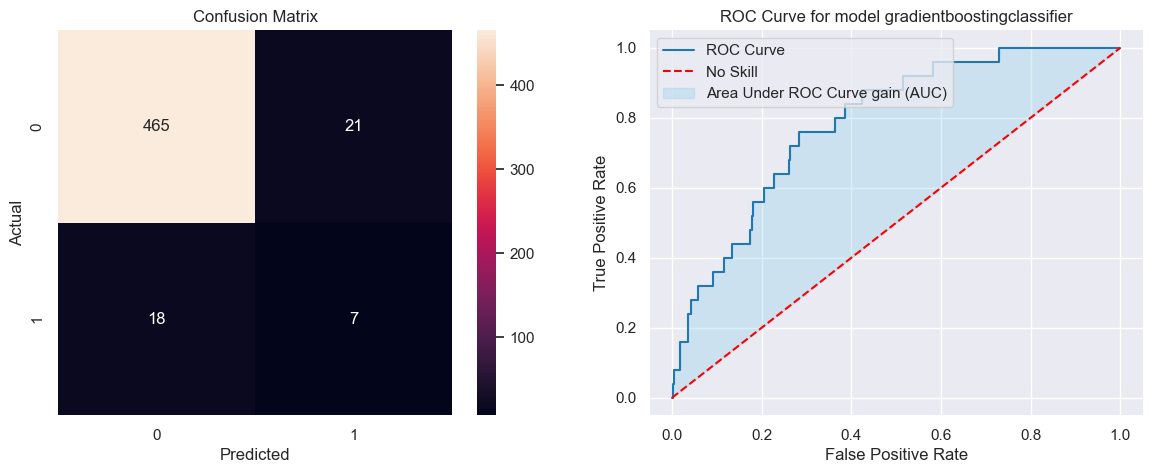

Results for xgbclassifier model:
Accuracy: 0.821917808219178
Precision: 0.48
Recall: 0.13333333333333333


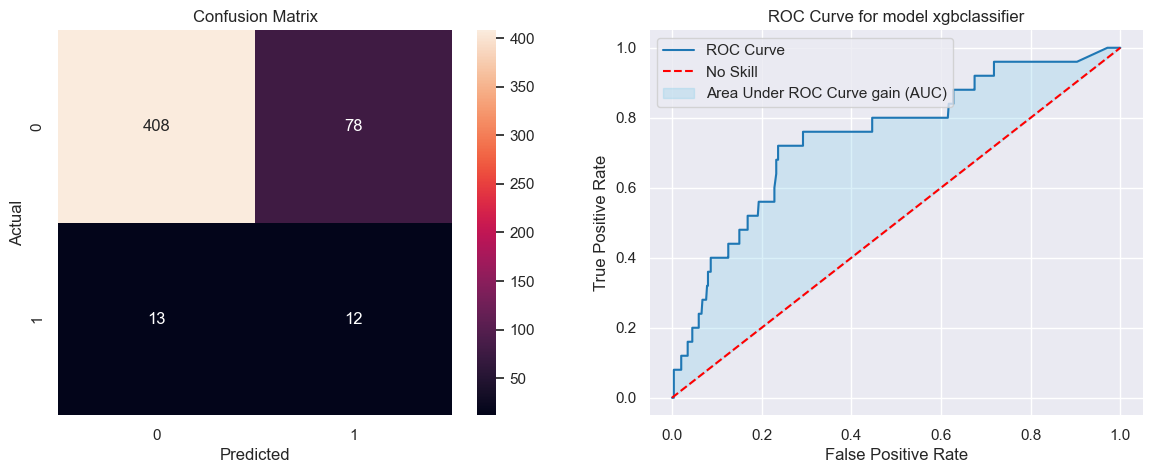

[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=40 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=40 will be ignored. Current value: min_data_in_leaf=30
Results for lgbmclassifier model:
Accuracy: 0.9158512720156555
Precision: 0.2
Recall: 0.17857142857142858


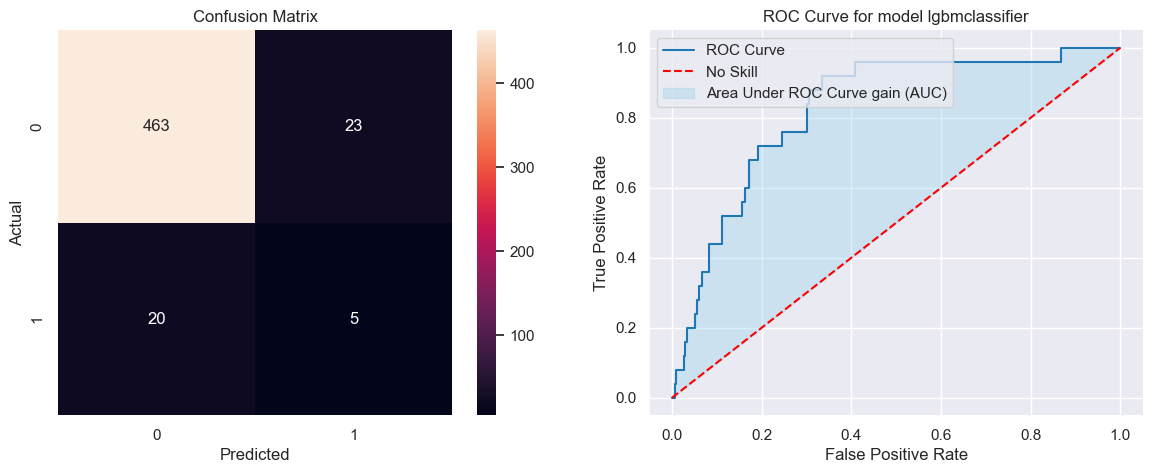

In [85]:
for i, model in enumerate(models):

    predictions = models[model].predict(X_test)
    probability_predictions = models[model].predict_proba(X_test)

    fn.model_performance_review(predictions, y_test,
                                probability_predictions[:, 1], model)

The Gradient Boosting Model & the XGBoost Model have very similar accuracy, precision and recall metrics. The LGBM classifier still had very good performance with above 90% accuracy, but lower precision and recalls. It seems like we have some really good models.

# Avenues for Improvement

* Cross Validation on the final testing procedure for the models. Because the numbers look a bit too good, I could have created different permutations of training and testing datasets to figure out the average of the performance metrics. Essentially, do final Cross Validation on the tuned models.
* Introduce Regularization into the models for enhanced general performance of the model.
* Create a composite model out of the three boosting models created with weights for enhanced prediction capabilities. 
* Use a more accurate model for the BMI missing data imputation.